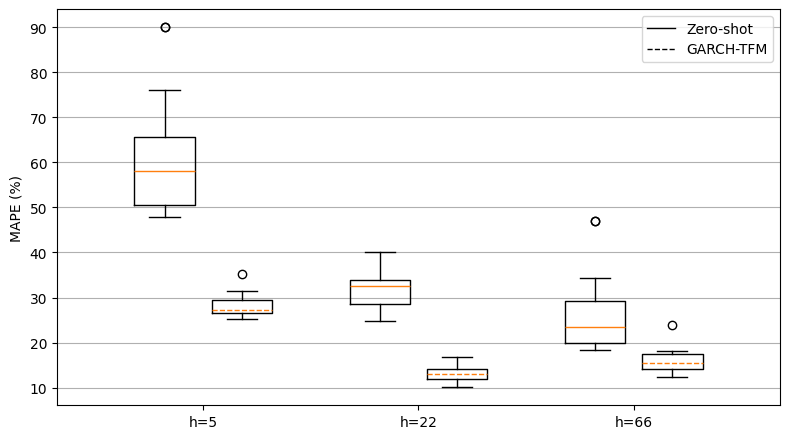

In [2]:
# Zero-shot vs Fine-tuned MAPE boxplots across horizons (h = 5, 22, 66)
# Two boxplots per horizon: left = zero-shot, right = fine-tuned.
# Y-axis: MAPE in %

import matplotlib.pyplot as plt

# ------------------ Assemble MAPE data ------------------
# Zero-shot MAPE (%) per horizon (include all rows provided, including duplicates across `normalize`)
zs_h5 = [
    76.1,57.7,47.8,76.1,57.7,47.8,
    70.5,62.0,51.6,70.5,62.0,51.6,
    65.7,69.2,58.5,65.7,69.2,58.5,
    52.4,56.7,90.0,52.4,56.7,90.0,
    58.5,50.1,50.0,58.5,50.1,50.0,
    62.9,50.5,48.2,62.9,50.5,48.2
]

zs_h22 = [
    28.6,33.9,27.3,28.6,33.9,27.3,
    32.1,37.2,32.9,32.1,37.2,32.9,
    32.7,40.1,34.3,32.7,40.1,34.3,
    27.1,35.2,32.4,27.1,35.2,32.4,
    33.5,32.9,29.5,33.5,32.9,29.5,
    30.6,27.5,24.9,30.6,27.5,24.9
]

zs_h66 = [
    19.9,34.4,26.4,19.9,34.4,26.4,
    22.3,46.9,26.6,22.3,46.9,26.6,
    20.0,30.1,23.5,20.0,30.1,23.5,
    19.4,31.3,24.3,19.4,31.3,24.3,
    18.4,23.3,18.4,18.4,23.3,18.4
]

# Fine-tuned MAPE (%) per horizon (from your unified table)
ft_h5 = [
    29.5, 27.9, 35.2,   # c=32,  f=0,1,2
    27.2, 27.2, 31.5,   # c=64,  f=0,1,2
    25.3, 25.7, 26.5    # c=128, f=0,1,2
]

# h = 22: c ∈ {32, 64, 128, 256}, f ∈ {0, 1, 2}
ft_h22 = [
    13.2, 13.7, 16.4,   # c=32,  f=0,1,2
    15.5, 12.8, 16.8,   # c=64,  f=0,1,2
    12.7, 13.4, 12.1,   # c=128, f=0,1,2
    10.1, 11.3, 10.1    # c=256, f=0,1,2
]

# h = 66: c ∈ {64, 128}, f ∈ {0, 1, 2}
ft_h66 = [
    15.4, 18.1, 23.8,   # c=64,  f=0,1,2
    12.3, 15.5, 13.7    # c=128, f=0,1,2
]

# Pack by horizon
zs_data = [zs_h5, zs_h22, zs_h66]
ft_data = [ft_h5, ft_h22, ft_h66]
horizons = [5, 22, 66]

# ------------------ Plot ------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

# For each horizon index i, place zero-shot at i-0.15 and fine-tuned at i+0.15
offset = 0.18
positions_zs = [i - offset for i in range(len(horizons))]
positions_ft = [i + offset for i in range(len(horizons))]

# Plot boxplots (matplotlib only; no seaborn)
bp_zs = ax.boxplot(zs_data, positions=positions_zs, widths=0.28, patch_artist=False)
bp_ft = ax.boxplot(ft_data, positions=positions_ft, widths=0.28, patch_artist=False)

# Differentiate fine-tuned by dashed median lines
for median in bp_ft['medians']:
    median.set_linestyle('--')

ax.set_xticks(range(len(horizons)))
ax.set_xticklabels([f"h={h}" for h in horizons])
ax.set_ylabel("MAPE (%)")

# Simple legend using dummy lines
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color='black', lw=1, label='Zero-shot'),
    Line2D([0], [0], color='black', lw=1, linestyle='--', label='GARCH-TFM'),
]
ax.legend(handles=legend_elems, loc='upper right')
ax.grid(axis='y')
fig.tight_layout()

# Save (optional)
# plt.savefig("timesfm_mape_boxes_zs_vs_ft.png", dpi=200, bbox_inches='tight')

plt.show()
